<a href="https://colab.research.google.com/github/HoangNguyennnnnnn/Kaggle/blob/main/Brain_Cancer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
orvile_brain_cancer_mri_dataset_path = kagglehub.dataset_download('orvile/brain-cancer-mri-dataset')

print('Data source import complete.')


Data source import complete.


In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

Streaming output truncated to the last 5000 lines.
/kaggle/input/brain-cancer-mri-dataset/Brain_Cancer raw MRI data/Brain_Cancer/brain_tumor/brain_tumor_0092.jpg
/kaggle/input/brain-cancer-mri-dataset/Brain_Cancer raw MRI data/Brain_Cancer/brain_tumor/brain_tumor_0121.jpg
/kaggle/input/brain-cancer-mri-dataset/Brain_Cancer raw MRI data/Brain_Cancer/brain_tumor/brain_tumor_1752.jpg
/kaggle/input/brain-cancer-mri-dataset/Brain_Cancer raw MRI data/Brain_Cancer/brain_tumor/brain_tumor_0977.jpg
/kaggle/input/brain-cancer-mri-dataset/Brain_Cancer raw MRI data/Brain_Cancer/brain_tumor/brain_tumor_1783.jpg
/kaggle/input/brain-cancer-mri-dataset/Brain_Cancer raw MRI data/Brain_Cancer/brain_tumor/brain_tumor_0030.jpg
/kaggle/input/brain-cancer-mri-dataset/Brain_Cancer raw MRI data/Brain_Cancer/brain_tumor/brain_tumor_1501.jpg
/kaggle/input/brain-cancer-mri-dataset/Brain_Cancer raw MRI data/Brain_Cancer/brain_tumor/brain_tumor_1883.jpg
/kaggle/input/brain-cancer-mri-dataset/Brain_Cancer raw MRI d

Epoch [1/10], Train Acc: 69.74%, Val Acc: 83.83%
Epoch [2/10], Train Acc: 83.26%, Val Acc: 86.06%
Epoch [3/10], Train Acc: 84.64%, Val Acc: 88.04%
Epoch [4/10], Train Acc: 85.78%, Val Acc: 87.87%
Epoch [5/10], Train Acc: 87.22%, Val Acc: 88.78%
Epoch [6/10], Train Acc: 86.46%, Val Acc: 88.61%
Epoch [7/10], Train Acc: 87.53%, Val Acc: 89.19%
Epoch [8/10], Train Acc: 87.16%, Val Acc: 89.85%
Epoch [9/10], Train Acc: 87.76%, Val Acc: 90.43%
Epoch [10/10], Train Acc: 88.11%, Val Acc: 90.02%
Model saved as vgg19_brain_cancer.pth


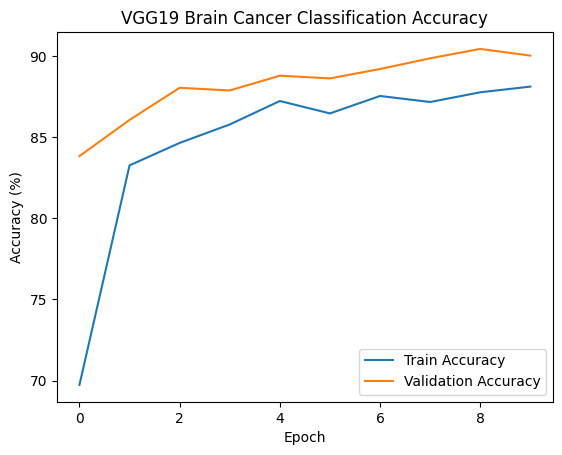

In [ ]:
import os
import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define data paths
data_dir = "/kaggle/input/brain-cancer-mri-dataset/Brain_Cancer raw MRI data/Brain_Cancer"

# Image transformations
transform = {
    'train': transforms.Compose([
        transforms.Resize((512, 512)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5])
    ]),
    'val': transforms.Compose([
        transforms.Resize((512, 512)),
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5])
    ]),
}

# Load dataset
batch_size = 16
train_data = datasets.ImageFolder(root=os.path.join(data_dir), transform=transform['train'])
train_size = int(0.8 * len(train_data))
val_size = len(train_data) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(train_data, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)

# Load VGG19
model = models.vgg19(weights=models.VGG19_Weights.IMAGENET1K_V1)
for param in model.parameters():
    param.requires_grad = False

# Modify classifier
model.classifier[6] = nn.Linear(4096, 3)
model = model.to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier[6].parameters(), lr=0.0001)

# Training
epochs = 10
train_acc, val_acc = [], []

for epoch in range(epochs):
    model.train()
    correct, total = 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    train_accuracy = 100 * correct / total
    train_acc.append(train_accuracy)

    # Validation
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
    val_accuracy = 100 * correct / total
    val_acc.append(val_accuracy)

    print(f"Epoch [{epoch+1}/{epochs}], Train Acc: {train_accuracy:.2f}%, Val Acc: {val_accuracy:.2f}%")

# Save model
torch.save(model.state_dict(), "vgg19_brain_cancer.pth")
print("Model saved as vgg19_brain_cancer.pth")

# Plot
plt.plot(train_acc, label='Train Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.title("VGG19 Brain Cancer Classification Accuracy")
plt.show()